# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haneen06-blip/flyrank-assiment/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [7]:
import os

print(os.listdir("/content"))
!git clone https://github.com/haneen06-blip/flyrank-assiment.git
import os

print(os.listdir("/content/flyrank-assiment/data/raw"))
import pandas as pd

df = pd.read_csv(
    "/content/flyrank-assiment/data/raw/content_refresh_anonymized.csv"
)

df.head()

['.config', 'flyrank-assiment', 'sample_data']
fatal: destination path 'flyrank-assiment' already exists and is not an empty directory.
['content_refresh_anonymized.csv']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. My rule and its reason codes

My rule prioritizes content that has a weak search position and low scroll engagement.

The score increases when avg_position is greater than 20.
The score also increases when scroll_rate is below 5.

Reason codes:
- POSITION_WEAK: avg_position > 20
- SCROLL_WEAK: scroll_rate < 5
- BOTH: both conditions are true
- NONE: neither condition is true

Higher scores get higher priority.

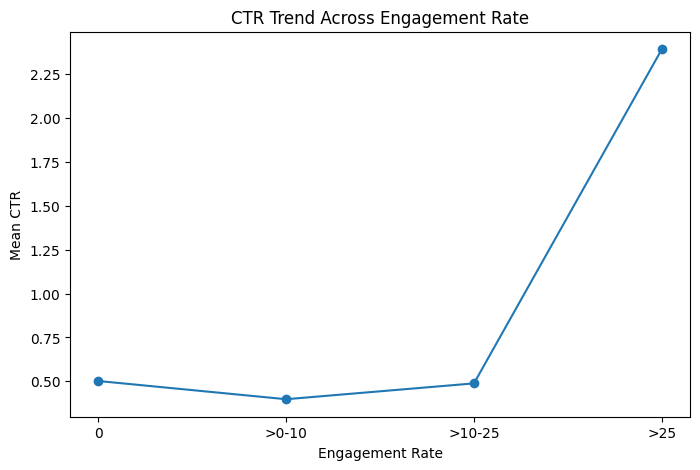

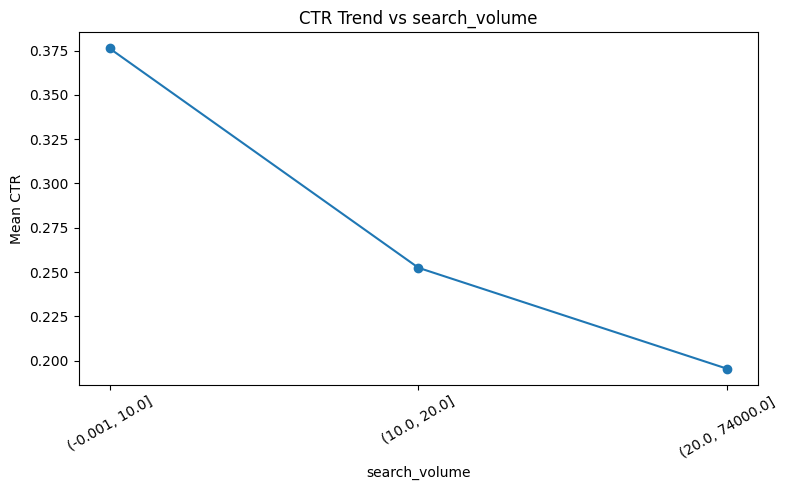

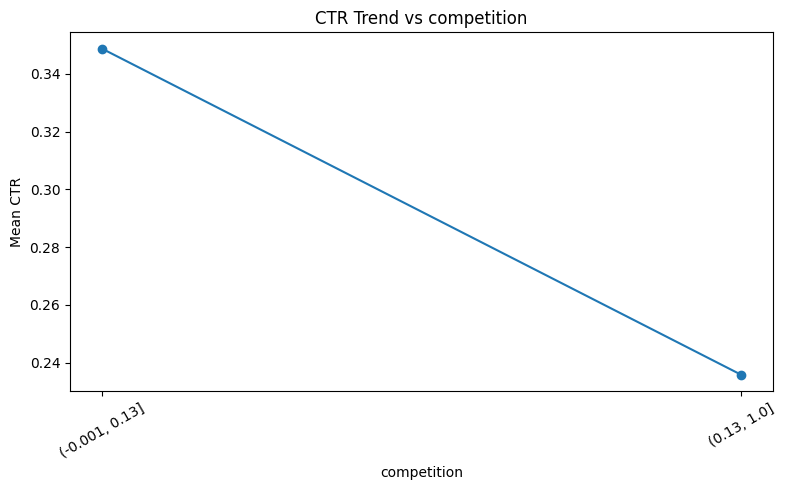

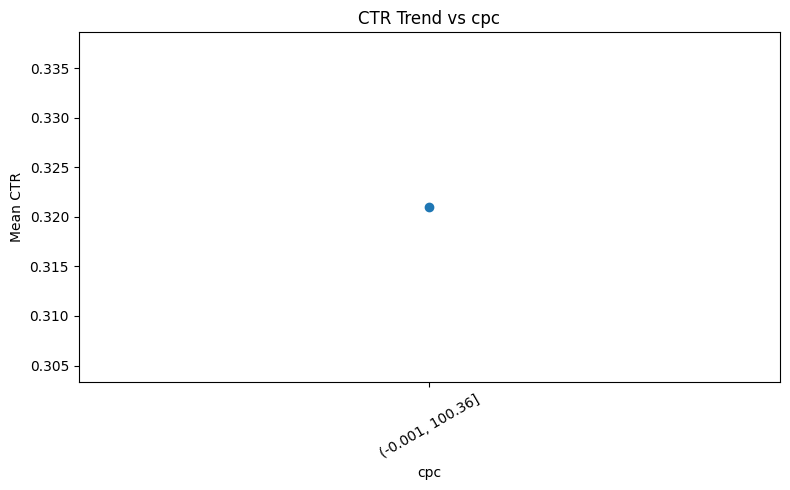

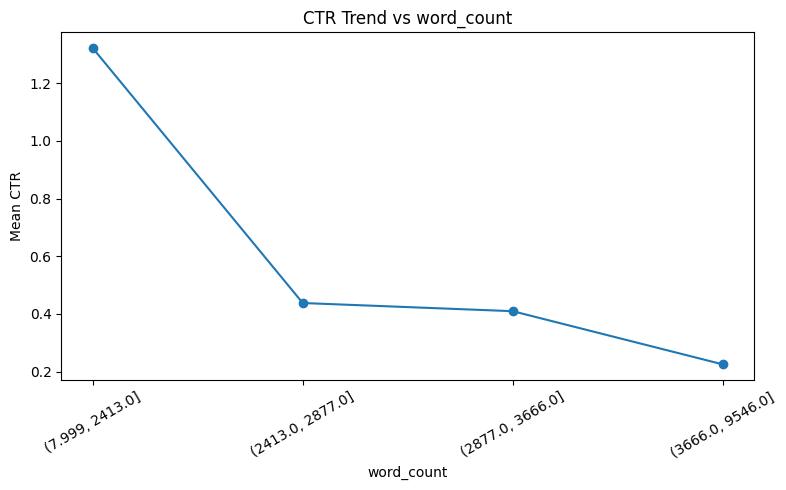

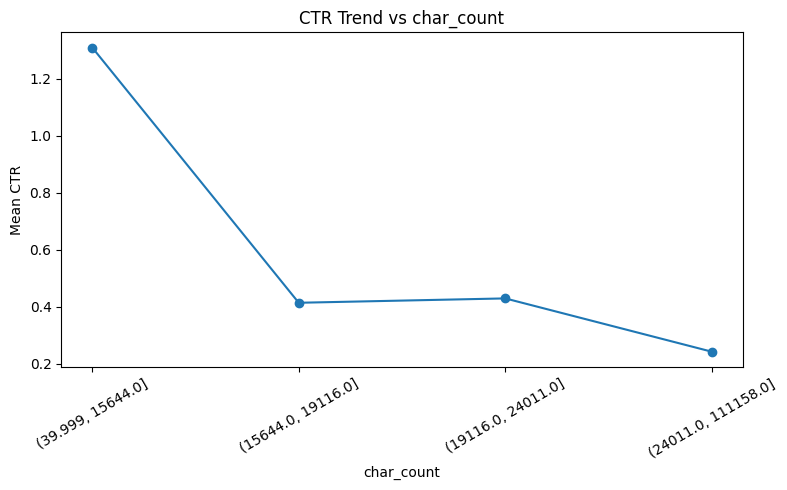

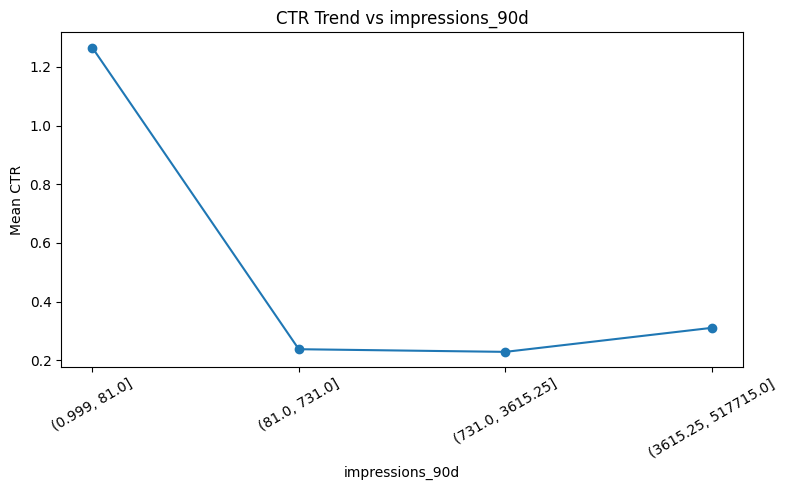

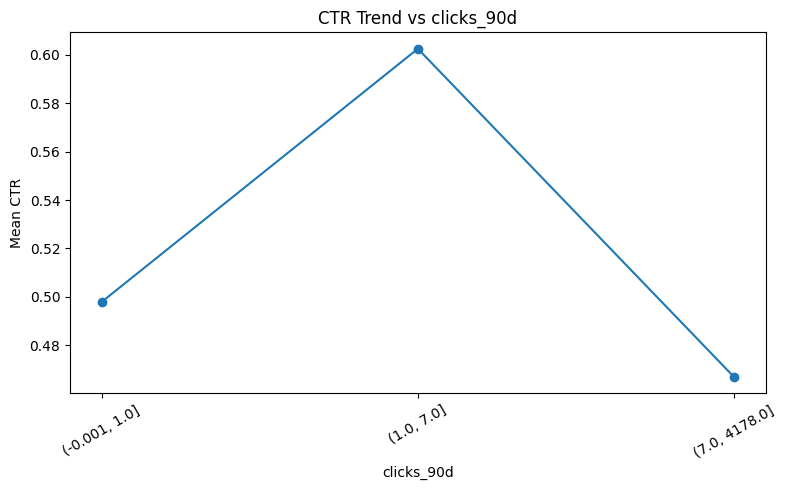

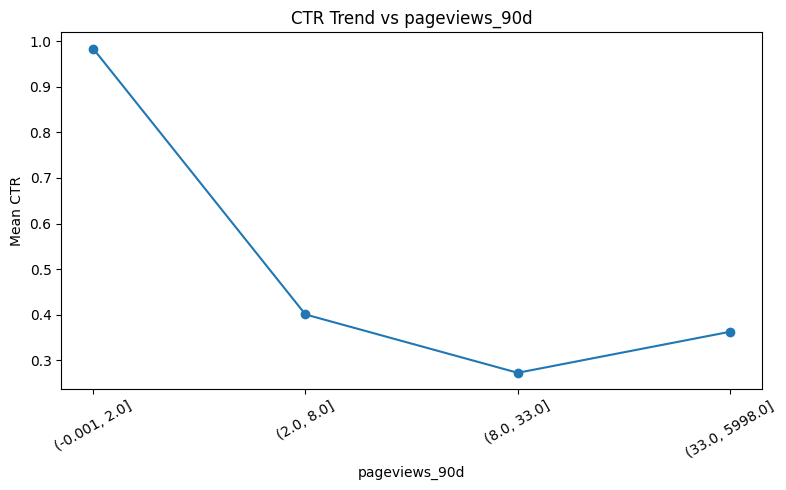

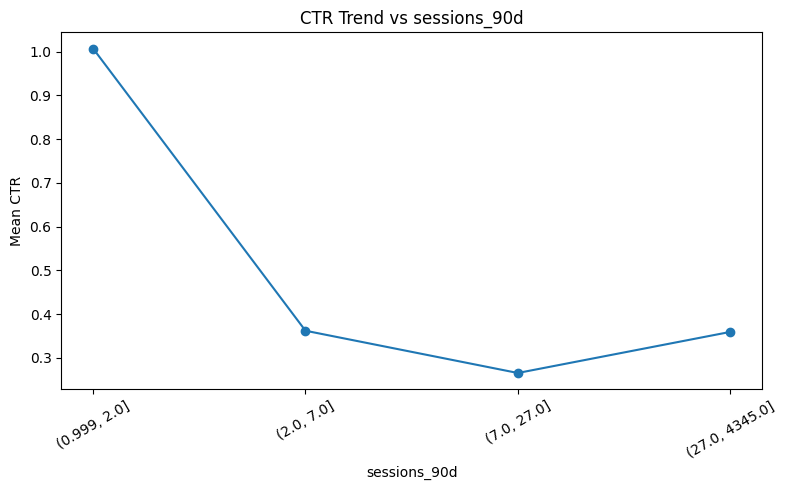

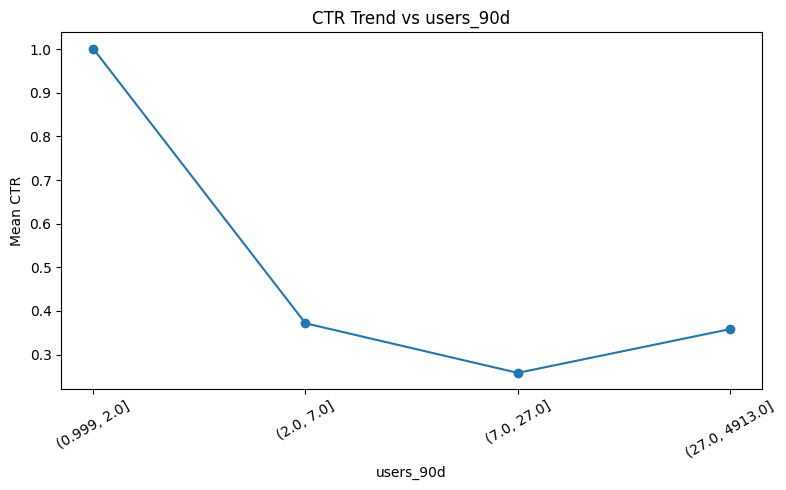

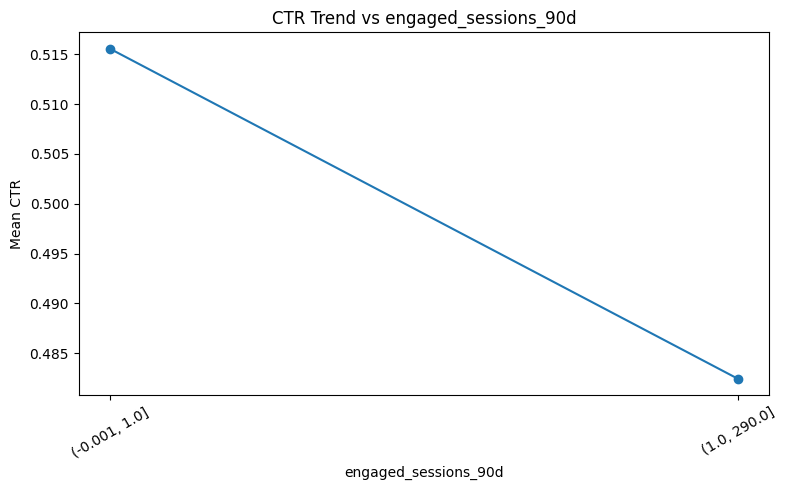

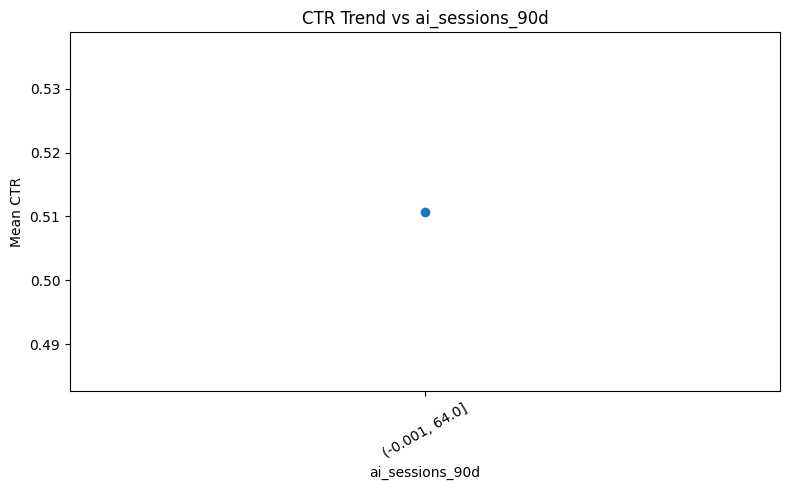

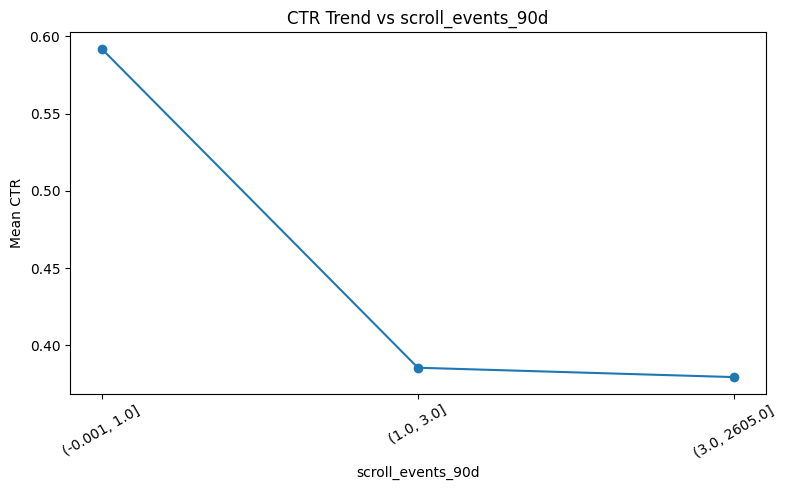

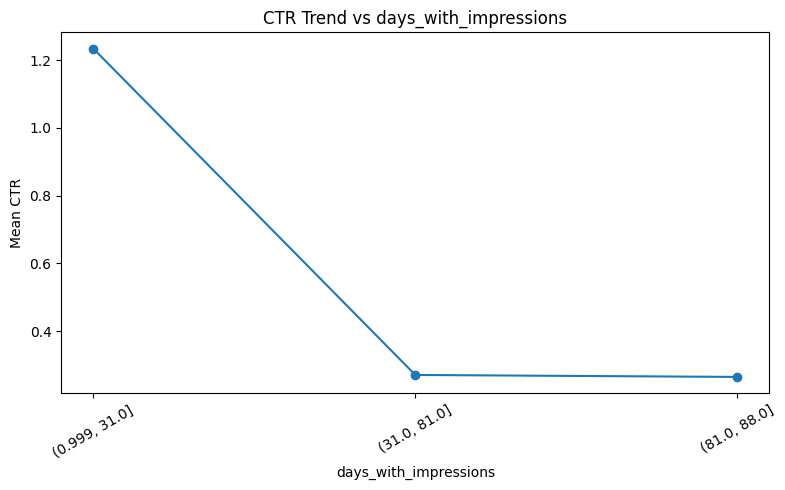

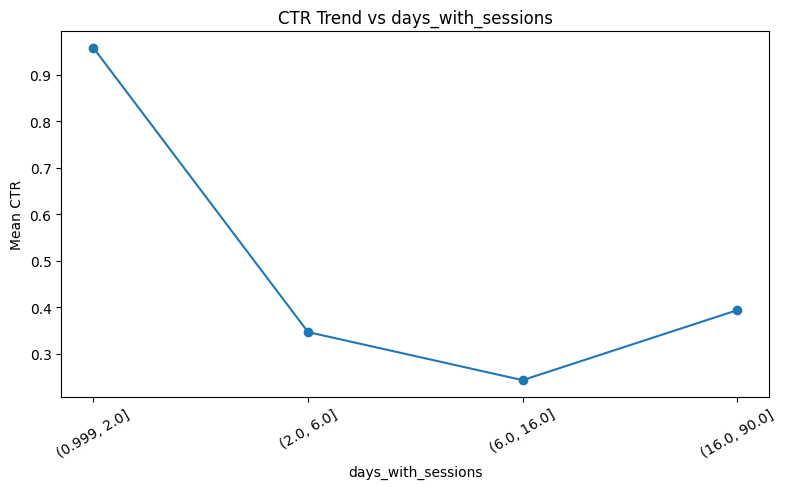

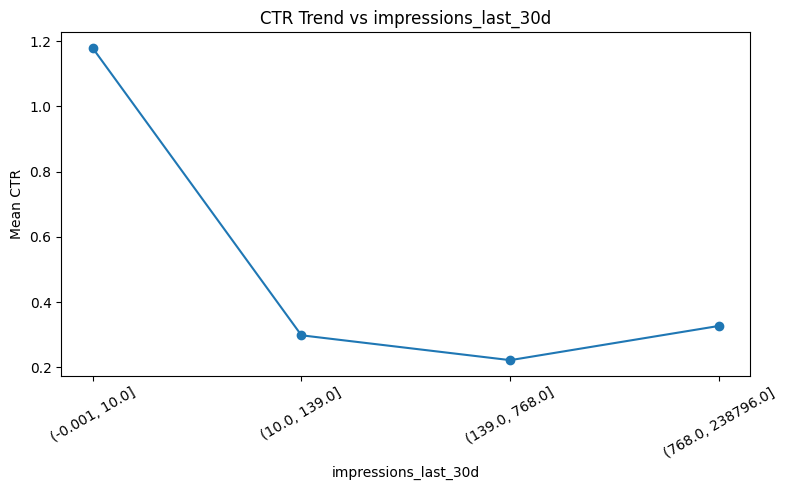

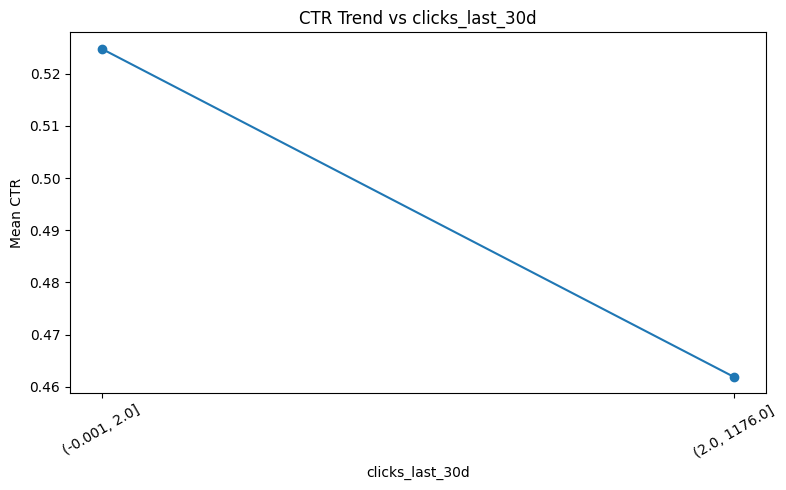

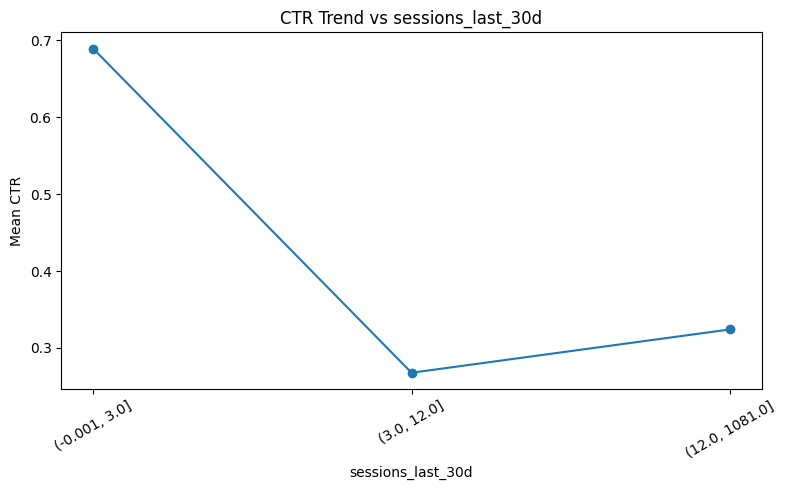

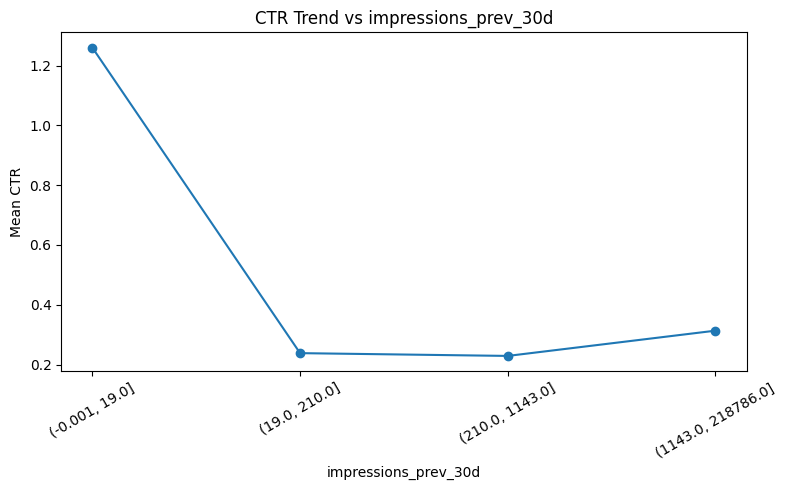

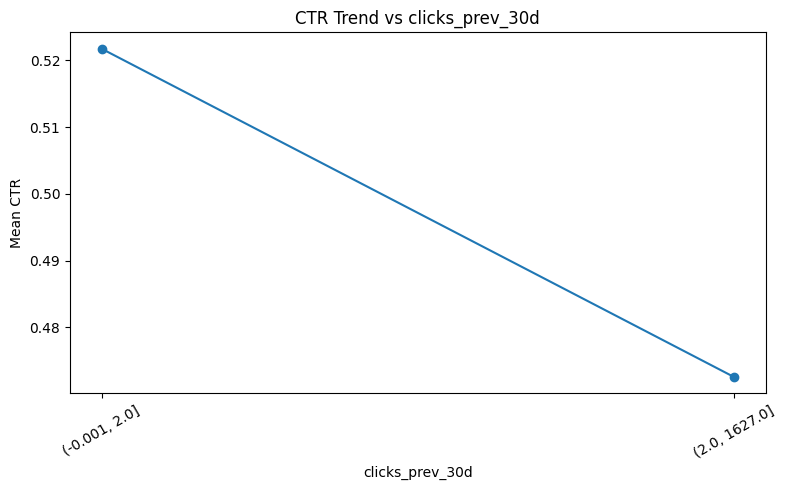

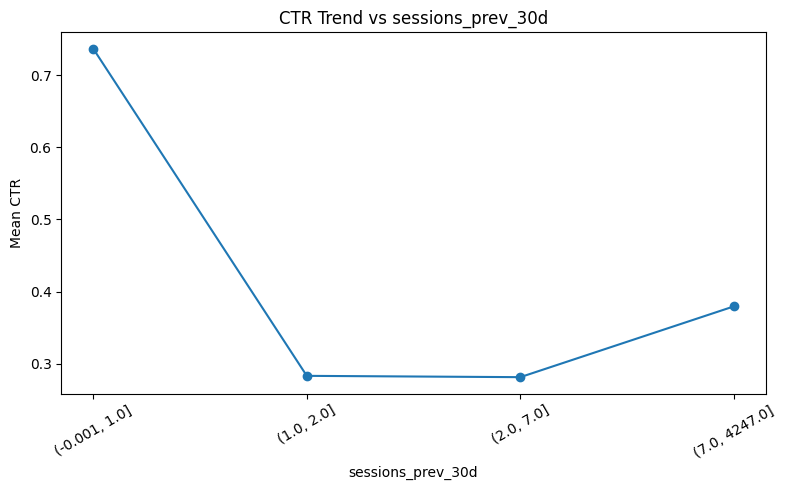

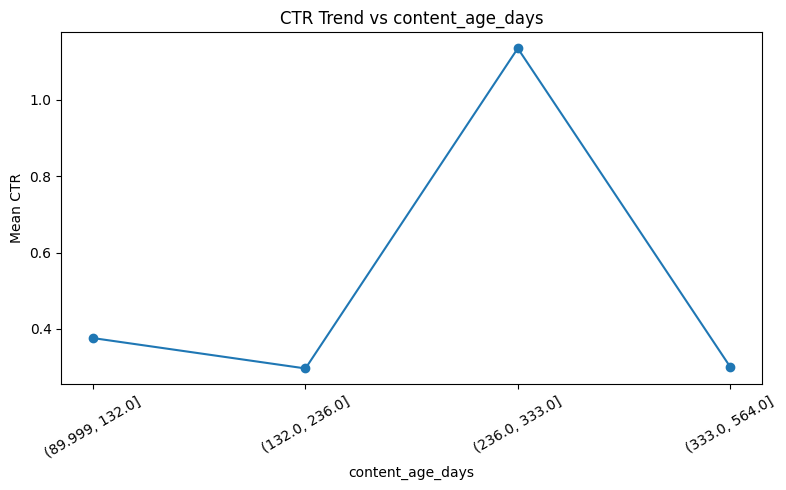

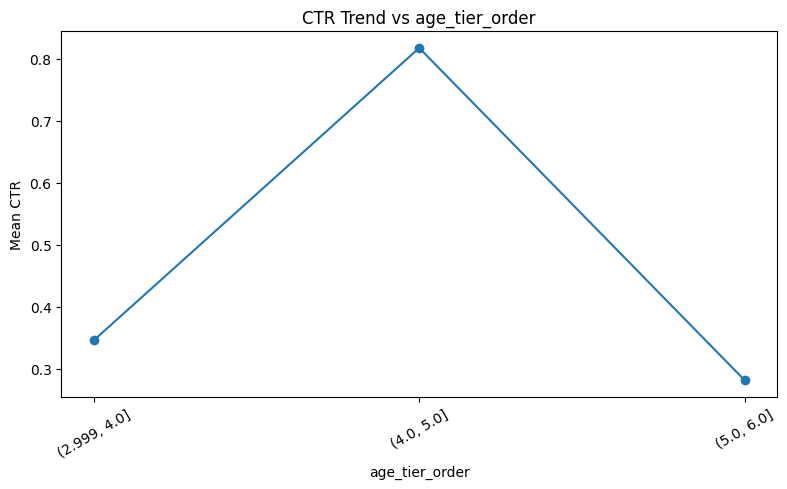

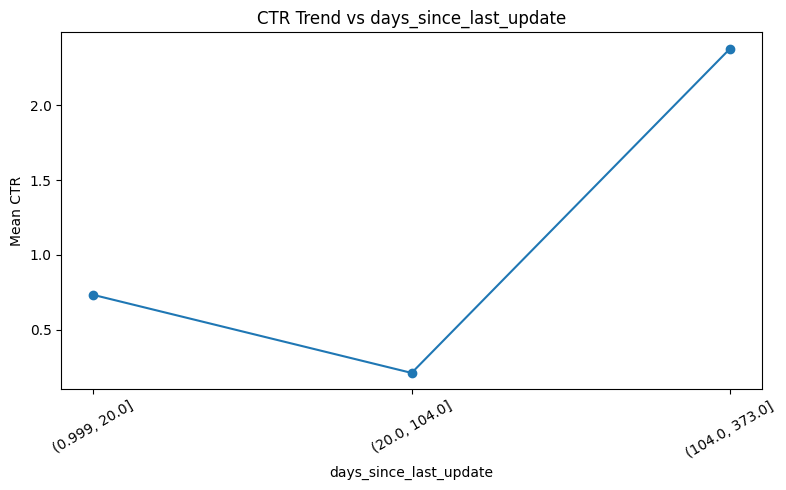

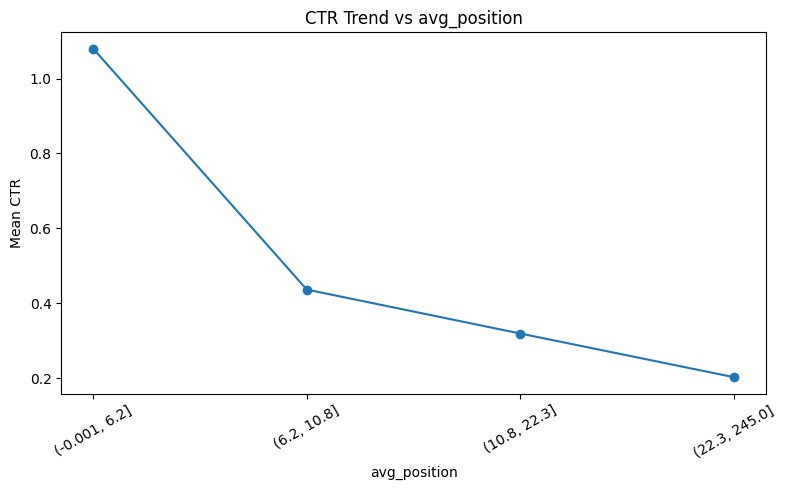

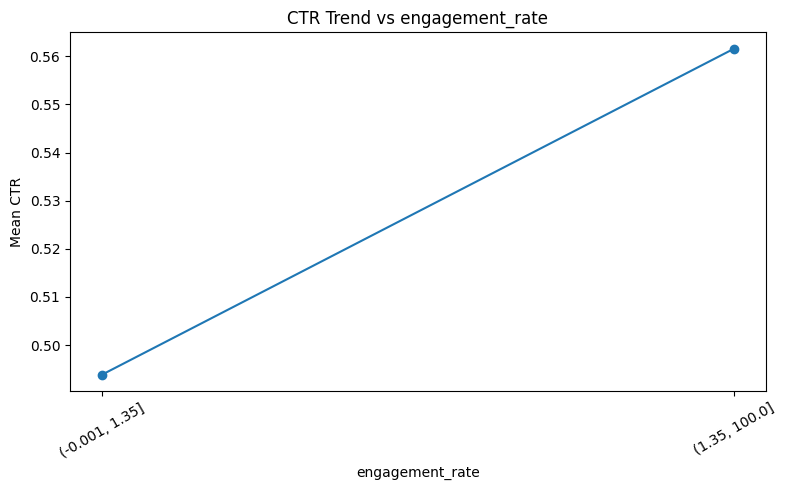

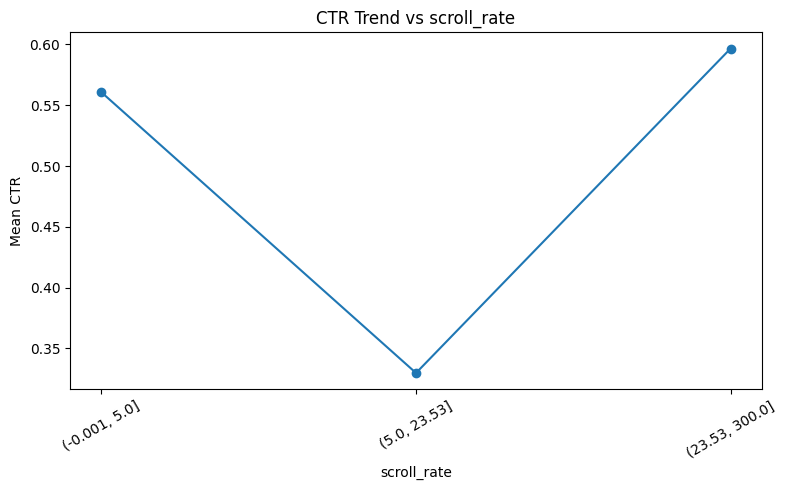

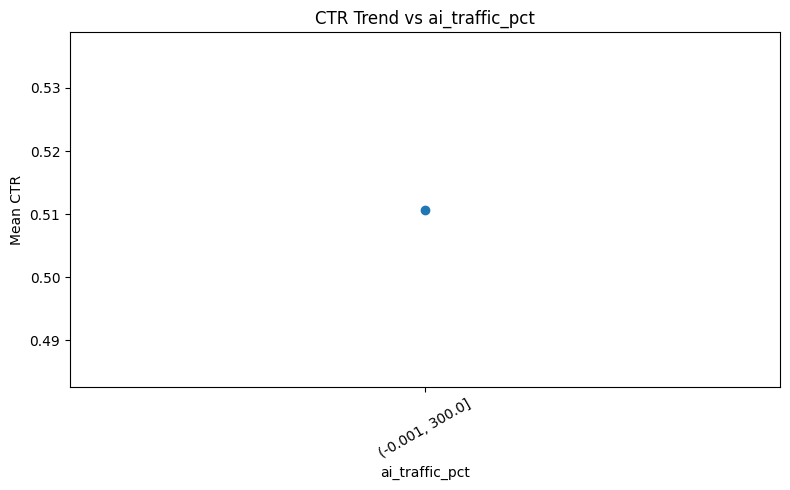

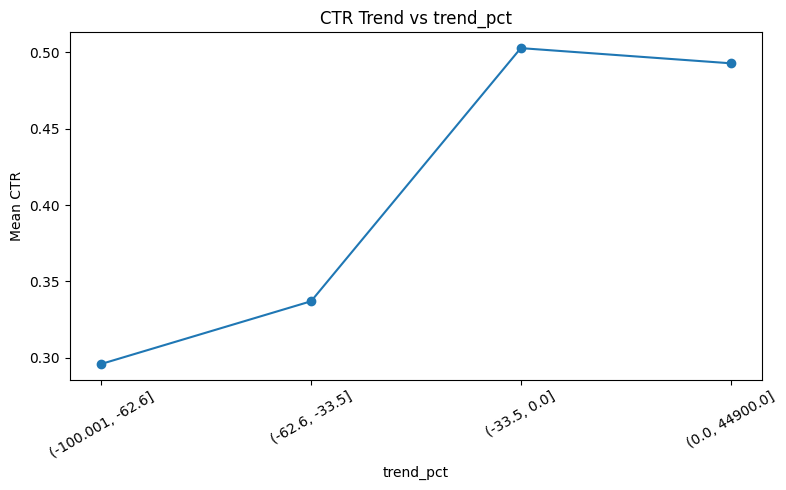

In [43]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df.describe().T
numeric_cols = df.select_dtypes(include="number").columns

correlations = (
    df[numeric_cols]
    .corr()["ctr"]
    .sort_values(ascending=False)
)

correlations
df["engagement_rate"].describe()
df["engagement_rate"].value_counts().head(20)
bins = [-0.01, 0, 10, 25, float("inf")]

df["engagement_bucket"] = pd.cut(
    df["engagement_rate"],
    bins=bins,
    labels=["0", ">0-10", ">10-25", ">25"],
    include_lowest=True
)

engagement_check = (
    df.groupby("engagement_bucket", observed=True)
      .agg(
          mean_ctr=("ctr", "mean"),
          n=("ctr", "size")
      )
      .reset_index()
)

engagement_check
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    engagement_check["engagement_bucket"].astype(str),
    engagement_check["mean_ctr"],
    marker="o"
)

plt.xlabel("Engagement Rate")
plt.ylabel("Mean CTR")
plt.title("CTR Trend Across Engagement Rate")

plt.show()
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    if col == "ctr":
        continue

    # تقسيم العمود إلى 4 مجموعات متساوية تقريبًا
    temp = df[[col, "ctr"]].dropna()

    try:
        temp["bucket"] = pd.qcut(
            temp[col],
            q=4,
            duplicates="drop"
        )

        grouped = (
            temp.groupby("bucket", observed=True)["ctr"]
            .mean()
            .reset_index()
        )

        plt.figure(figsize=(8, 5))

        plt.plot(
            range(len(grouped)),
            grouped["ctr"],
            marker="o"
        )

        plt.xticks(
            range(len(grouped)),
            grouped["bucket"].astype(str),
            rotation=30
        )

        plt.xlabel(col)
        plt.ylabel("Mean CTR")
        plt.title(f"CTR Trend vs {col}")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Skipped {col}: {e}")


In [44]:
df[["avg_position", "scroll_rate"]].quantile([0.25, 0.50, 0.75])

,avg_position,scroll_rate
0.25,6.2,0.00
0.50,10.8,5.00
0.75,22.3,23.53


## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

In [45]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import pandas as pd

# Make a copy so we don't accidentally change the original data
score_df = df.copy()

# 1 point for weak search position
score_df["position_flag"] = (
    score_df["avg_position"] > 20
).astype(int)

# 1 point for low scroll engagement
score_df["scroll_flag"] = (
    score_df["scroll_rate"] < 5
).astype(int)

# Total score: 0, 1, or 2
score_df["baseline_score"] = (
    score_df["position_flag"] +
    score_df["scroll_flag"]
)

# Reason code
score_df["reason_code"] = "NONE"

score_df.loc[
    (score_df["position_flag"] == 1) &
    (score_df["scroll_flag"] == 0),
    "reason_code"
] = "POSITION_WEAK"

score_df.loc[
    (score_df["position_flag"] == 0) &
    (score_df["scroll_flag"] == 1),
    "reason_code"
] = "SCROLL_WEAK"

score_df.loc[
    (score_df["position_flag"] == 1) &
    (score_df["scroll_flag"] == 1),
    "reason_code"
] = "BOTH"

# Action
score_df["action"] = "MONITOR"

score_df.loc[
    score_df["baseline_score"] == 1,
    "action"
] = "REVIEW"

score_df.loc[
    score_df["baseline_score"] == 2,
    "action"
] = "PRIORITIZE"

# Rank highest score first
score_df = score_df.sort_values(
    ["baseline_score", "avg_position"],
    ascending=[False, False]
).reset_index(drop=True)

score_df["rank"] = range(1, len(score_df) + 1)

# Output folder
os.makedirs(
    "/content/flyrank-assiment/work/outputs",
    exist_ok=True
)

# Write CSV
output_path = (
    "/content/flyrank-assiment/work/outputs/"
    "baseline_action_score.csv"
)

score_df.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Rows:", len(score_df))


Saved: /content/flyrank-assiment/work/outputs/baseline_action_score.csv
Rows: 30000


In [46]:
score_df[
    [
        "content_id",
        "baseline_score",
        "reason_code",
        "action",
        "rank"
    ]
].head(20)

,content_id,baseline_score,reason_code,action,rank
0,content_23f1cc8851a9,2,BOTH,PRIORITIZE,1
1,content_7275a6a3a8eb,2,BOTH,PRIORITIZE,2
2,content_71a31b831092,2,BOTH,PRIORITIZE,3
3,content_42c7c72b8391,2,BOTH,PRIORITIZE,4
4,content_3e087a5d8f15,2,BOTH,PRIORITIZE,5
5,content_13bbd72aea33,2,BOTH,PRIORITIZE,6
6,content_abeb1aa40158,2,BOTH,PRIORITIZE,7
7,content_388cdca878d0,2,BOTH,PRIORITIZE,8
8,content_0616953c1f57,2,BOTH,PRIORITIZE,9
9,content_50c5853287f0,2,BOTH,PRIORITIZE,10


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

In [48]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
top20_review = top20[
    [
        "rank",
        "content_id",
        "avg_position",
        "scroll_rate",
        "reason_code",
        "action"
    ]
].copy()

top20_review["confidence_note"] = (
    "Moderate confidence: both rule signals are present, "
    "but this is a decision-support baseline, not proof of poor content quality."
)

top20_review["what_would_make_it_wrong"] = (
    "The priority could be wrong if the position or scroll signal is noisy, "
    "if the page has a valid reason for low engagement, or if other context is missing."
)

top20_review

,rank,content_id,avg_position,scroll_rate,reason_code,action,confidence_note,what_would_make_it_wrong
0,1,content_23f1cc8851a9,184.0,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
1,2,content_7275a6a3a8eb,165.5,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
2,3,content_71a31b831092,161.0,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
3,4,content_42c7c72b8391,145.5,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
4,5,content_3e087a5d8f15,138.8,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
5,6,content_13bbd72aea33,118.0,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
6,7,content_abeb1aa40158,113.5,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
7,8,content_388cdca878d0,110.0,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
8,9,content_0616953c1f57,108.4,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...
9,10,content_50c5853287f0,105.5,0.0,BOTH,PRIORITIZE,Moderate confidence: both rule signals are pre...,The priority could be wrong if the position or...


## 4. Weak picks + leakage check

Some picks may be weak because the baseline uses only two signals and does not include all business context.

A pick could be wrong if low scroll rate is normal for the content type, if average position is affected by other factors, or if the observed signals are noisy.

No product decision flags are used as features. The baseline was built only from observable dataset columns.

No future windows are used in the score. The rule uses current observable signals only.

In [49]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Check that no product decision flags were used
product_flag_names = [
    "health_score",
    "priority_score",
    "action_type",
    "refresh_tier",
    "needs_ctr_fix",
    "is_quick_win"
]

used_columns = ["avg_position", "scroll_rate"]

print("Signals used:", used_columns)

print("\nProduct flags present in dataset:")
print([c for c in product_flag_names if c in df.columns])

print("\nFuture-looking columns used in score:")
print([])

Signals used: ['avg_position', 'scroll_rate']

Product flags present in dataset:
[]

Future-looking columns used in score:
[]


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.